In [1]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

Question 1: Then, use the "GraidentTape API" to find the derivative of the function f(x) = sin(x) for x = 0, 0.1, 0.2 and 0.3. Submit your Jupyter notebook that shows both the code and the result you got.

In [2]:
xs = [
      tf.Variable(0.0),
      tf.Variable(0.1),
      tf.Variable(0.2),
      tf.Variable(0.3)
    ]

dy_dxs = []

for x in xs:
  with tf.GradientTape() as tape:
    y = tf.sin(x)

  dy_dx = tape.gradient(y, x)
  dy_dxs.append(dy_dx.numpy())

dy_dxs

[1.0, 0.9950042, 0.9800666, 0.9553365]

Question 2: Then, for the task "Classifying movie reviews: A binary classification example", tune the hyper-parameters of the model (such as changing the number of layers, changing the sizes of layers, changing the optimizer, changing the learning rate, etc.), and see if you can improve the model's performance. Submit a Jupyter notebook where you clearly show the code with the best hyper-parameters that you have found, along with its performance on training, validation and test sets.

In [3]:
!pip install keras_tuner
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import keras_tuner as kt
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb

# %% colab_type="code"
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

# %% colab_type="code"
word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.2 MB/s eta 0:00:00
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# %% colab_type="code"
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
X_train = vectorize_sequences(train_data)
X_test = vectorize_sequences(test_data)

# %% colab_type="code"
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")# %% colab_type="code"

X_val = X_train[:10000]
partial_X_train = X_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [5]:
def build_model(hp):
    # Define hyperparameters
    units1 = hp.Int('units1', min_value=16, max_value=32, step=16)
    units2 = hp.Int('units2', min_value=16, max_value=32, step=16)
    optimizer = hp.Choice('optimizer', ['rmsprop', 'adam'])
    learning_rate = hp.Choice('learning_rate', [0.001, 0.01])

    # Define optimizer with learning rate
    if optimizer == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer}")

    # Build model
    model = keras.Sequential([
        layers.Dense(units1, activation="relu"),
        layers.Dense(units2, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Initialize the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_tuner_dir',
    project_name='homework2'
)

In [6]:
print("Searching")
tuner.search(partial_X_train, partial_y_train, epochs=5, validation_split=0.2)

# After the search is complete, get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print the best hyperparameters
print("Best Hyperparameters:")
print(f"units1: {best_hps.get('units1')}")
print(f"units2: {best_hps.get('units2')}")
print(f"optimizer: {best_hps.get('optimizer')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")

Trial 10 Complete [00h 00m 23s]
val_accuracy: 0.8683333396911621

Best val_accuracy So Far: 0.8823333382606506
Total elapsed time: 00h 03m 52s
Best Hyperparameters:
units1: 32
units2: 32
optimizer: rmsprop
learning_rate: 0.001


In [7]:
model = tuner.hypermodel.build(best_hps)
history = model.fit(partial_X_train, partial_y_train, epochs=5, validation_split=0.2)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8005 - loss: 0.4454 - val_accuracy: 0.8640 - val_loss: 0.3367
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9352 - loss: 0.1835 - val_accuracy: 0.8773 - val_loss: 0.3232
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9531 - loss: 0.1311 - val_accuracy: 0.8743 - val_loss: 0.3672
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9666 - loss: 0.0942 - val_accuracy: 0.8707 - val_loss: 0.4340
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9816 - loss: 0.0559 - val_accuracy: 0.8690 - val_loss: 0.5033


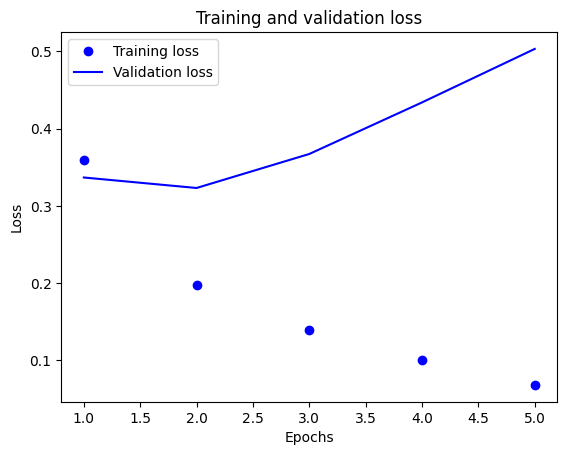

In [8]:
# %% [markdown] colab_type="text"
# **Plotting the training and validation loss**

# %% colab_type="code"
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
model = tuner.hypermodel.build(best_hps)
history = model.fit(partial_X_train, partial_y_train, epochs=5, validation_split=0.2)

val_acc_per_epoch = history.history['val_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
# best_epoch = 5
print('Best epoch: %d' % (best_epoch,))

hypermodel = tuner.hypermodel.build(best_hps)
history = hypermodel.fit(partial_X_train, partial_y_train, epochs=best_epoch, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7975 - loss: 0.4374 - val_accuracy: 0.8727 - val_loss: 0.3106
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9338 - loss: 0.1791 - val_accuracy: 0.8817 - val_loss: 0.3195
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9597 - loss: 0.1195 - val_accuracy: 0.8740 - val_loss: 0.3756
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9730 - loss: 0.0836 - val_accuracy: 0.8710 - val_loss: 0.4586
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9820 - loss: 0.0522 - val_accuracy: 0.8660 - val_loss: 0.5753
Best epoch: 2
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7987 - loss: 0.4386 - val_accuracy: 0.8820 - val_loss: 0.2978
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9316 - loss: 0.1818 - val_accuracy: 0.8780 - val_loss: 0.3365


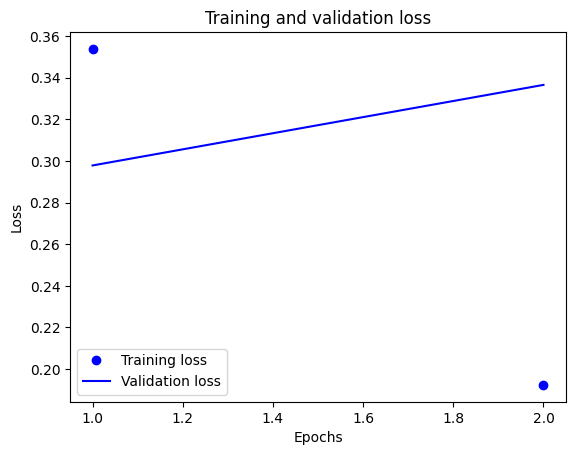

In [15]:
# %% [markdown] colab_type="text"
# **Plotting the training and validation loss**

# %% colab_type="code"
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
eval_result = hypermodel.evaluate(X_val, y_val)
print("[test loss, test accuracy]:", eval_result)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8794 - loss: 0.3094
[test loss, test accuracy]: [0.31300199031829834, 0.8806999921798706]
